* sprawdzić, czy podmiany zaszły tylko POZA scaffoldami
* inny typ data splitu - clustering-based, time-based, scaffold(?)
* poprawić komórkę z wyborem TOP5

In [2]:
import pandas as pd
import numpy as np

from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator, AllChem, Draw
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.rdChemReactions import ReactionFromSmarts

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

import warnings

RDLogger.DisableLog("rdApp.*")
warnings.filterwarnings("ignore", module="upsetplot")

seed = 8

In [3]:
data = pd.read_csv("all_chem_df.csv")

data["tags"] = data["tags"].fillna("").str.split()
data = data.drop(["image_name", "Col3"], axis=1)
data = data[sorted(data.columns)]

data.head()

,smiles,tags
0,CC(=O)NC1C(O)OC(CO)C(O)C1O,[dermatologic]
1,CCC[C@@]1(CCc2ccccc2)CC(O)=C([C@H](CC)c2cccc(N...,[antiinfective]
2,CCCCC(C)C(=O)OC1C(C)C(CC)OC2(CC3CC(C/C=C(\C)CC...,[antiinfective]
3,COc1cc2c(c(OC)c1OC)-c1c(cc3c(c1OC)OCO3)C[C@H](...,[antineoplastic]
4,CC(=O)N[C@@H](CS)C(=O)[O-],"[antiinfective, respiratorysystem]"


# TYLKO SINGLE LABEL 

In [ ]:
data = data[data["tags"].apply(len) == 1].copy()
data["tags"] = data["tags"].apply(lambda x: x[0])
data = data.reset_index(drop=True)

data.head()

,smiles,tags
0,CC(=O)NC1C(O)OC(CO)C(O)C1O,dermatologic
1,CCC[C@@]1(CCc2ccccc2)CC(O)=C([C@H](CC)c2cccc(N...,antiinfective
2,CCCCC(C)C(=O)OC1C(C)C(CC)OC2(CC3CC(C/C=C(\C)CC...,antiinfective
3,COc1cc2c(c(OC)c1OC)-c1c(cc3c(c1OC)OCO3)C[C@H](...,antineoplastic
4,CC(=O)OCC(=O)C1CCC2C3CCC4CC(O)CCC4(C)C3C(=O)CC12C,cns


In [ ]:
def sanitize_smiles(smiles):
    if not isinstance(smiles, str):
        return None
        
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
        
    try:
        #fragment_chooser = rdMolStandardize.LargestFragmentChooser()
        #mol = fragment_chooser.choose(mol)
        
        #uncharger = rdMolStandardize.Uncharger()
        #mol = uncharger.uncharge(mol)
        """wyłączyłem póki co te modyfikacje"""
        Chem.SanitizeMol(mol)
        
        return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
        
    except Exception as e:
        return None

def generate_mol(smiles):
    if not isinstance(smiles, str):
        return None
    return Chem.MolFromSmiles(smiles)

def generate_fp(mol, radius=2, nBits=2048):
    if mol is not None:
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
        return np.array(fp)
    else:
        return np.zeros(nBits)

In [ ]:
data["smiles"] = data["smiles"].apply(sanitize_smiles)
data["mol"] = data["smiles"].apply(generate_mol)
data["fingerprint"] = data["mol"].apply(generate_fp)

In [ ]:
data

,smiles,tags,mol,fingerprint
0,CC(=O)NC1C(O)OC(CO)C(O)C1O,dermatologic,<rdkit.Chem.rdchem.Mol object at 0x178d3e1f0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CCC[C@@]1(CCc2ccccc2)CC(O)=C([C@H](CC)c2cccc(N...,antiinfective,<rdkit.Chem.rdchem.Mol object at 0x178ef9540>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CCCCC(C)C(=O)OC1C(C)C(CC)OC2(CC3CC(C/C=C(\C)CC...,antiinfective,<rdkit.Chem.rdchem.Mol object at 0x178ef95b0>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, ..."
3,COc1cc2c(c(OC)c1OC)-c1c(cc3c(c1OC)OCO3)C[C@H](...,antineoplastic,<rdkit.Chem.rdchem.Mol object at 0x178ef9620>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
4,CC(=O)OCC(=O)C1CCC2C3CCC4CC(O)CCC4(C)C3C(=O)CC12C,cns,<rdkit.Chem.rdchem.Mol object at 0x178ef9690>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...
6981,CC(=O)Oc1ccccc1C(=O)O.OCCN(CCO)c1nc(N2CCCCC2)c...,hematologic,<rdkit.Chem.rdchem.Mol object at 0x301321d90>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6982,C=CO.C=O,hematologic,<rdkit.Chem.rdchem.Mol object at 0x301321e00>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6983,CC1(C)SC2[C@H](NC(=O)[C@H](N)c3ccccc3)C(=O)N2[...,antiinfective,<rdkit.Chem.rdchem.Mol object at 0x301321e70>,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
6984,COCCCOc1ccnc(C[S@@](=O)c2nc3ccccc3[nH]2)c1C,gastrointestinal,<rdkit.Chem.rdchem.Mol object at 0x301321ee0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."


In [ ]:
bioisosteric_reactions = {
    "Cl_to_F": "[Cl:1]>>[F:1]",
    "F_to_Cl": "[F:1]>>[Cl:1]",
    "OH_to_NH2": "[O;H1:1]>>[N;H2:1]",
    "NH2_to_OH": "[N;H2:1]>>[O;H1:1]",
    "COOH_to_CONH2": "[C:2](=[O:3])[O;H1:1]>>[C:2](=[O:3])[N;H2:1]",
    "CONH2_to_COOH": "[C:2](=[O:3])[N;H2:1]>>[C:2](=[O:3])[O;H1:1]"
}

reactions = {k: ReactionFromSmarts(v) for k, v in bioisosteric_reactions.items()}

In [ ]:
updated_bioisosteric_reactions = {
    "COOH_to_tetrazole": "[*:1]C(=O)[O;H1]>>[*:1]c1nn[nH]n1",
    "tetrazole_to_COOH": "[*:1]c1nn[nH]n1>>[*:1]C(=O)O",
    "COOH_to_acyl_sulfonamide": "[*:1]C(=O)[O;H1]>>[*:1]C(=O)NS(=O)=O",
    "amide_to_reverse_amide": "[*:1]C(=O)N[*:2]>>[*:1]NC(=O)[*:2]",
    "amide_to_urea": "[*:1]C(=O)N[*:2]>>[*:1]NC(=O)N[*:2]",
    "amide_to_sulfonamide": "[*:1]C(=O)N[*:2]>>[*:1]S(=O)(=O)N[*:2]",
}

updated_reactions = {k: ReactionFromSmarts(v) for k, v in updated_bioisosteric_reactions.items()}

In [ ]:
smiles_arr = data["smiles"].to_numpy() 
fp_arr = np.stack(data["fingerprint"].values) 

rows = []

for tag, positions in sorted(data.groupby("tags").indices.items()):
    fps = fp_arr[positions]
    n = len(fps)

    # Podobieństwo cząsteczki do samej siebie = 1.0
    sim_sums = np.ones(n, dtype=float)

    #tanimoto distance 
    if n > 1:
        for i in range(1, n):
            intersection = np.dot(fps[:i], fps[i])
            sum_A = np.sum(fps[:i], axis=1)
            sum_B = np.sum(fps[i])
            
            sims = intersection / (sum_A + sum_B - intersection)
            
            sim_sums[i] += sims.sum()
            sim_sums[:i] += sims

    #podobieństwo do reszty grupy
    mean_tanimoto = sim_sums / n
    
    #sortowanie malejąco i wybór max 5 indeksów
    top_idx = np.argsort(-mean_tanimoto)[:min(5, n)]

    for local_idx in top_idx:
        pos = positions[local_idx]
        rows.append(
            {
                "tags": tag,
                "original_smiles": smiles_arr[pos],
                "mean_tanimoto_to_tag": mean_tanimoto[local_idx],
            }
        )

top5_by_tag = pd.DataFrame(rows)
top5_by_tag

,tags,original_smiles,mean_tanimoto_to_tag
0,antiinfective,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,0.144221
1,antiinfective,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,0.143854
2,antiinfective,CO/N=C(/C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...,0.143450
3,antiinfective,CON=C(C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)=O...,0.143450
4,antiinfective,CO/N=C(/C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)...,0.143450
5,antiinflammatory,CC(=O)OCC(=O)[C@@]1(O)[C@@H](C)C[C@H]2[C@@H]3C...,0.190715
6,antiinflammatory,CC(=O)OCC(=O)[C@@]1(O)[C@@H](C)C[C@H]2C3CCC4=C...,0.190715
7,antiinflammatory,CC(=O)OCC(=O)[C@@]1(O)[C@H](C)C[C@H]2C3CCC4=CC...,0.190715
8,antiinflammatory,CC(=O)OCC(=O)[C@@]1(O)[C@@H](C)CC2C3CCC4=CC(=O...,0.190715
9,antiinflammatory,CC(=O)OCC(=O)[C@@]1(O)[C@H](C)C[C@H]2[C@@H]3CC...,0.190715


In [ ]:
reaction_results = []

for index, row in top5_by_tag.iterrows():
    tag = row["tags"]
    original_smiles = row["original_smiles"]
    mean_tanimoto = row["mean_tanimoto_to_tag"]
    
    mol = Chem.MolFromSmiles(original_smiles)
    if mol is None:
        continue

    for rxn_name, rxn in updated_reactions.items():
        # krotka krotek z produktami reakcji
        products = rxn.RunReactants((mol,))
        
        #(set) zeby usunąć identyczne produkty = symetryczne smilesy powstałe w wyniku reakcji
        unique_new_smiles = set()
        
        for product_tuple in products:
            product_mol = product_tuple[0]
            
            try:
                product_smiles = sanitize_smiles(Chem.MolToSmiles(product_mol))
                if product_smiles is not None:
                    unique_new_smiles.add(product_smiles)
                    
            except Exception:
                pass
                
        for new_smiles in unique_new_smiles:
            if new_smiles != original_smiles:
                reaction_results.append({
                    "original_tag": tag,
                    "original_smiles": original_smiles,
                    "mean_tanimoto_to_tag": mean_tanimoto,
                    "reaction_type": rxn_name,
                    "new_smiles": new_smiles
                })

isosteric_reactions_df = pd.DataFrame(reaction_results)
print(f"Wygenerowano {len(isosteric_reactions_df)} izosterów.")

Wygenerowano 196 izosterów.


In [ ]:
isosteres_data = pd.DataFrame({
    "original_smiles": isosteric_reactions_df["original_smiles"],
    "reaction_type": isosteric_reactions_df["reaction_type"],
    "isostere_smiles": isosteric_reactions_df["new_smiles"]
})

isosteres_data = isosteres_data.drop_duplicates(subset=["isostere_smiles"]).reset_index(drop=True)
isosteres_data["mol"] = isosteres_data["isostere_smiles"].apply(generate_mol)
isosteres_data["fingerprint"] = isosteres_data["mol"].apply(generate_fp)

isosteres_data

,original_smiles,reaction_type,isostere_smiles,mol,fingerprint
0,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,COOH_to_tetrazole,COCC1=C(c2nn[nH]n2)N2C(=O)[C@@H](NC(=O)/C(=N\O...,<rdkit.Chem.rdchem.Mol object at 0x302e7b0d0>,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,COOH_to_acyl_sulfonamide,COCC1=C(C(=O)N[SH](=O)=O)N2C(=O)[C@@H](NC(=O)/...,<rdkit.Chem.rdchem.Mol object at 0x302e7a1f0>,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,amide_to_reverse_amide,COCC1=C(C(=O)O)C(=O)N[C@@H](NC(=O)/C(=N\OC)c2c...,<rdkit.Chem.rdchem.Mol object at 0x302c9d540>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,amide_to_reverse_amide,COCC(=CC(=O)O)CS[C@H]1C(=O)N[C@H]1NC(=O)/C(=N\...,<rdkit.Chem.rdchem.Mol object at 0x302c9c040>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,amide_to_reverse_amide,COCC1=C(C(=O)O)N2C(=O)[C@@H](C(=O)N/C(=N\OC)c3...,<rdkit.Chem.rdchem.Mol object at 0x302c9d460>,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...,...,...,...
180,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,amide_to_sulfonamide,O=S(=O)(NCCc1ccccc1[CH]c1ccccc1)OC1CN2CCC1CC2,<rdkit.Chem.rdchem.Mol object at 0x302caa2d0>,"[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
181,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,amide_to_sulfonamide,CCc1ccccc1[C@@H](NS(=O)(=O)OC1CN2CCC1CC2)c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x302ca9f50>,"[0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
182,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,amide_to_reverse_amide,CCc1ccccc1[C@H](C(=O)NOC1CN2CCC1CC2)c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x302caa3b0>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
183,O=C(O)CCC(=O)O.O=C(OC1CN2CCC1CC2)N1CCc2ccccc2[...,amide_to_urea,CCc1ccccc1[C@H](NC(=O)NOC1CN2CCC1CC2)c1ccccc1,<rdkit.Chem.rdchem.Mol object at 0x302caa030>,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [ ]:
X = np.stack(data["fingerprint"].values)
#zamiana stringów na liczby całkowite
le = LabelEncoder()
y = le.fit_transform(data["tags"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state = seed, stratify=y
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}\n")

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state = seed, n_jobs=-1),
    "SVM": SVC(kernel="rbf", probability=True, random_state = seed),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state = seed)
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    trained_models[name] = model
    print(f"{name}: accuracy: {acc:.4f}\n")

Train set size: 5588
Test set size: 1398

Random Forest: accuracy: 0.8541

SVM: accuracy: 0.8019



/Users/franekkarpinski/miniconda3/envs/cleanenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [10:42:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: accuracy: 0.8240



In [ ]:
#wektory cech dla izosterów
X_iso = np.stack(isosteres_data["fingerprint"].values)

#mapujemy oryginalne tagi z DF "data" na podstawie "original_smiles"
oryginalne_tagi_dict = dict(zip(data["smiles"], data["tags"]))
isosteres_data["original_tag"] = isosteres_data["original_smiles"].map(oryginalne_tagi_dict)

for name, model in trained_models.items():
    predykcje_liczbowe = model.predict(X_iso)
    
    #dekodujemy liczby na nazwy klas
    predykcje_tekstowe = le.inverse_transform(predykcje_liczbowe)
    
    kolumna_pred = f"Predykcja_{name}"
    isosteres_data[kolumna_pred] = predykcje_tekstowe
    
    kolumna_zmiana = f"Zmiana aktywnosci {name}"
    isosteres_data[kolumna_zmiana] = isosteres_data["original_tag"] != isosteres_data[kolumna_pred]

kolumny_do_wyswietlenia = [
    "original_smiles", "reaction_type", "isostere_smiles", "original_tag",
    "Predykcja_Random Forest", "Zmiana aktywnosci Random Forest",
    "Predykcja_SVM", "Zmiana aktywnosci SVM",
    "Predykcja_XGBoost", "Zmiana aktywnosci XGBoost"
]

print("Zmiana przewidywanego labela")
for name in trained_models.keys():
    liczba_zmian = isosteres_data[f"Zmiana aktywnosci {name}"].sum()
    procent = (liczba_zmian / len(isosteres_data)) * 100
    print(f"{name}: {liczba_zmian} z {len(isosteres_data)} ({procent:.1f}%)")

Zmiana przewidywanego labela
Random Forest: 32 z 185 (17.3%)
SVM: 35 z 185 (18.9%)
XGBoost: 41 z 185 (22.2%)


In [ ]:
changed_isosteres_df = isosteres_data[
    (isosteres_data["Zmiana aktywnosci XGBoost"] == True) | 
    (isosteres_data["Zmiana aktywnosci Random Forest"] == True) |
    (isosteres_data["Zmiana aktywnosci SVM"] == True)
].copy()
changed_isosteres_df = changed_isosteres_df.reset_index(drop=True)

kolumny_do_analizy = [
    "original_smiles",
    "reaction_type",
    "isostere_smiles",
    "original_tag",
    "Predykcja_Random Forest",
    "Predykcja_SVM",
    "Predykcja_XGBoost"
]

changed_isosteres_df[kolumny_do_analizy]

,original_smiles,reaction_type,isostere_smiles,original_tag,Predykcja_Random Forest,Predykcja_SVM,Predykcja_XGBoost
0,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,amide_to_reverse_amide,CC(=O)OCC1=C(C(=O)O)C(=O)N[C@@H](NC(=O)[C@H](N...,antiinfective,antiinfective,cardio,antiinfective
1,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,amide_to_reverse_amide,CC(=O)OCC(=CC(=O)O)CS[C@H]1C(=O)N[C@H]1NC(=O)[...,antiinfective,cns,cns,antiinfective
2,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,amide_to_urea,CC(=O)OCC1=C(C(=O)O)NC(=O)N[C@@H](NC(=O)[C@H](...,antiinfective,antiinfective,cns,antiinfective
3,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,amide_to_urea,CC(=O)OCC(=CC(=O)O)CS[C@H]1NC(=O)N[C@H]1NC(=O)...,antiinfective,cns,cns,antineoplastic
4,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,amide_to_sulfonamide,CC(=O)OCC(=CC(=O)O)CS[C@H]1NS(=O)(=O)[C@H]1NC(...,antiinfective,cns,cns,antiinfective
5,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,amide_to_sulfonamide,CC(=O)OCC1=C(C(=O)O)NS(=O)(=O)[C@@H](NC(=O)[C@...,antiinfective,antiinfective,cardio,antiinfective
6,CCOC(=O)[C@H](CCc1ccccc1)N[C@@H](C)C(=O)N1CCC[...,COOH_to_acyl_sulfonamide,CCOC(=O)[C@H](CCc1ccccc1)N[C@@H](C)C(=O)N1CCC[...,cardio,cardio,cardio,cns
7,CCOC(=O)[C@H](CCc1ccccc1)N[C@@H](C)C(=O)N1CCC[...,amide_to_reverse_amide,CCC[C@@H](C(=O)O)C(=O)N[C@H](C)N[C@@H](CCc1ccc...,cardio,cardio,cardio,cns
8,CCOC(=O)[C@@H](CCc1ccccc1)N[C@@H](C)C(=O)N1CCC...,COOH_to_acyl_sulfonamide,CCOC(=O)[C@@H](CCc1ccccc1)N[C@@H](C)C(=O)N1CCC...,cardio,cardio,cardio,cns
9,CCOC(=O)[C@@H](CCc1ccccc1)N[C@@H](C)C(=O)N1CCC...,amide_to_reverse_amide,CCC[C@@H](C(=O)O)C(=O)N[C@H](C)N[C@H](CCc1cccc...,cardio,cardio,cardio,cns


/Users/franekkarpinski/miniconda3/envs/cleanenv/lib/python3.12/site-packages/rdkit/Chem/Draw/IPythonConsole.py:261: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


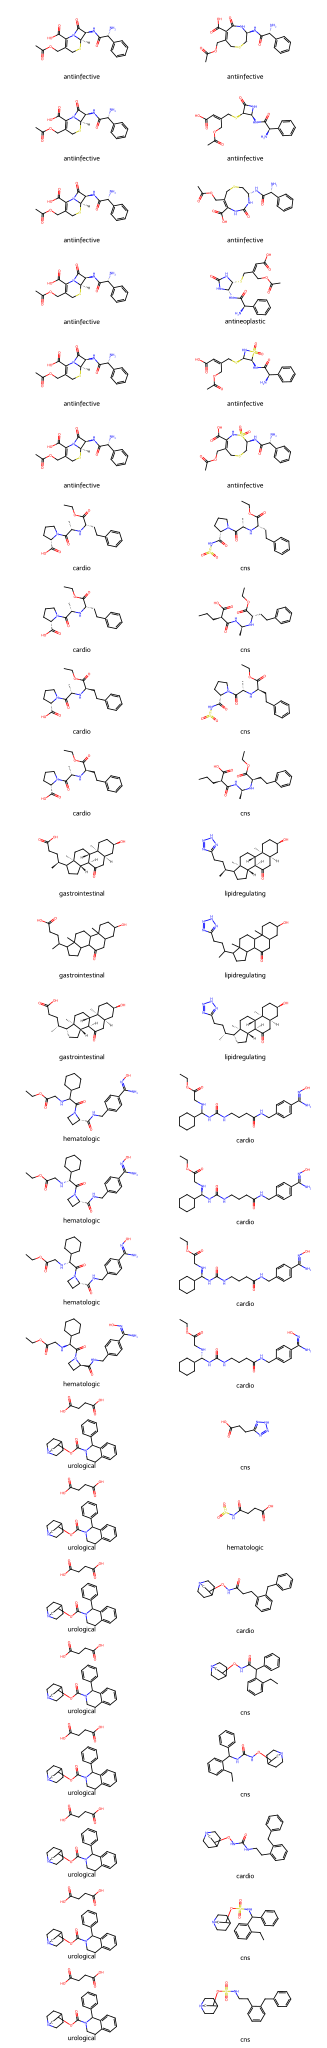

In [ ]:
mols_to_draw = []
legends = []

for index, row in changed_isosteres_df.iterrows():
    orig_mol = Chem.MolFromSmiles(row["original_smiles"])
    new_mol = Chem.MolFromSmiles(row["isostere_smiles"])
    
    if orig_mol is not None and new_mol is not None:
        mols_to_draw.extend([orig_mol, new_mol])
        
        legends.append(str(row["original_tag"]))
        legends.append(str(row["Predykcja_XGBoost"]))

img = Draw.MolsToGridImage(
    mols_to_draw,
    legends=legends,
    molsPerRow=2,
    subImgSize=(400, 200), 
    useSVG=True 
)

display(img)

# MULTI LABEL - CAŁE DANE

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
data = pd.read_csv("all_chem_df.csv")
data["tags"] = data["tags"].fillna("").str.split()
data = data.drop(["image_name", "Col3"], axis=1, errors='ignore')
data = data[sorted(data.columns)]

In [ ]:
data["smiles"] = data["smiles"].apply(sanitize_smiles)
data["mol"] = data["smiles"].apply(generate_mol)
data["fingerprint"] = data["mol"].apply(generate_fp)
data = data.dropna(subset=['mol']).reset_index(drop=True)

In [ ]:
smiles_arr = data["smiles"].to_numpy()
fp_arr = np.stack(data["fingerprint"].values)

all_unique_tags = sorted(set(tag for sublist in data['tags'] for tag in sublist))

In [ ]:
rows = []

for tag in all_unique_tags:
    positions = data[data['tags'].apply(lambda x: tag in x)].index.tolist()
    
    if not positions:
        continue
        
    fps = fp_arr[positions]
    n = len(fps)
    sim_sums = np.ones(n, dtype=float)

    if n > 1:
        for i in range(1, n):
            intersection = np.dot(fps[:i], fps[i])
            sum_A = np.sum(fps[:i], axis=1)
            sum_B = np.sum(fps[i])
            
            sims = intersection / (sum_A + sum_B - intersection)
            sim_sums[i] += sims.sum()
            sim_sums[:i] += sims

    mean_tanimoto = sim_sums / n
    top_idx = np.argsort(-mean_tanimoto)[:min(5, n)]

    for local_idx in top_idx:
        pos = positions[local_idx]
        rows.append({
            "tags": tag,
            "original_smiles": smiles_arr[pos],
            "mean_tanimoto_to_tag": mean_tanimoto[local_idx],
        })

top5_by_tag = pd.DataFrame(rows)

In [ ]:
mlb = MultiLabelBinarizer()
y_multi = mlb.fit_transform(data["tags"])
X = np.stack(data["fingerprint"].values)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_multi, test_size=0.2, random_state=seed
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}\n")

models_multi = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=seed, n_jobs=-1),
    #"SVM": OneVsRestClassifier(SVC(kernel="rbf", probability=True, random_state=seed)),
    "XGBoost": OneVsRestClassifier(XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=seed))
}

trained_models_multi = {}

for name, model in models_multi.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='micro')
    
    trained_models_multi[name] = model
    print(f"{name}: Accuracy: {acc:.4f}, F1-Score: {f1:.4f}")

Train set size: 6668
Test set size: 1668

Random Forest: Accuracy: 0.6888, F1-Score: 0.8165


/Users/franekkarpinski/miniconda3/envs/cleanenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:49:17] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/franekkarpinski/miniconda3/envs/cleanenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:49:18] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/franekkarpinski/miniconda3/envs/cleanenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:49:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/franekkarpinski/miniconda3/envs/cleanenv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [14:49:21] WARNING: /Users/

XGBoost: Accuracy: 0.6499, F1-Score: 0.7840


In [ ]:
X_iso = np.stack(isosteres_data["fingerprint"].values)

oryginalne_tagi_dict = dict(zip(data["smiles"], data["tags"]))
isosteres_data["original_tags"] = isosteres_data["original_smiles"].map(oryginalne_tagi_dict)

for name, model in trained_models_multi.items():
    predykcje_binarne = model.predict(X_iso)
    
    predykcje_tekstowe = mlb.inverse_transform(predykcje_binarne)
    
    kolumna_pred = f"Predykcja_{name}"
    isosteres_data[kolumna_pred] = [list(tags) for tags in predykcje_tekstowe]
    
    kolumna_zmiana = f"Zmiana_aktywnosci_{name}"
    isosteres_data[kolumna_zmiana] = [
        set(orig) != set(pred) 
        for orig, pred in zip(isosteres_data["original_tags"], isosteres_data[kolumna_pred])
    ]

kolumny_do_wyswietlenia = [
    "original_smiles", "reaction_type", "isostere_smiles", "original_tags",
    "Predykcja_Random Forest", "Zmiana_aktywnosci_Random Forest",
    #"Predykcja_SVM", "Zmiana_aktywnosci_SVM",
    "Predykcja_XGBoost", "Zmiana_aktywnosci_XGBoost"
]

print("Zmiana przewidywanego labela")
for name in trained_models_multi.keys():
    liczba_zmian = isosteres_data[f"Zmiana_aktywnosci_{name}"].sum()
    procent = (liczba_zmian / len(isosteres_data)) * 100
    print(f"{name}: {liczba_zmian} z {len(isosteres_data)} ({procent:.1f}%)")
    
isosteres_data[kolumny_do_wyswietlenia]

Zmiana przewidywanego labela
Random Forest: 1 z 109 (0.9%)
XGBoost: 16 z 109 (14.7%)


,original_smiles,reaction_type,isostere_smiles,original_tags,Predykcja_Random Forest,Zmiana_aktywnosci_Random Forest,Predykcja_XGBoost,Zmiana_aktywnosci_XGBoost
0,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,OH_to_NH2,COCC1=C(C(N)=O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,[antiinfective],[antiinfective],False,[antiinfective],False
1,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,NH2_to_OH,COCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)/C(=N\OC)c3...,[antiinfective],[antiinfective],False,[antiinfective],False
2,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,OH_to_NH2,CC(=O)OCC1=C(C(N)=O)N2C(=O)[C@@H](NC(=O)[C@H](...,[antiinfective],[antiinfective],False,[antiinfective],False
3,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,NH2_to_OH,CC(=O)OCC1=C(C(=O)O)N2C(=O)[C@@H](NC(=O)[C@H](...,[antiinfective],[antiinfective],False,[antiinfective],False
4,CON=C(C(=O)N[C@@H]1C(=O)N2C(C(=O)O)=C(COC(C)=O...,OH_to_NH2,CON=C(C(=O)N[C@@H]1C(=O)N2C(C(N)=O)=C(COC(C)=O...,[antiinfective],[antiinfective],False,[antiinfective],False
...,...,...,...,...,...,...,...,...
104,CC(C)[N+]1(C)[C@@H]2CC[C@H]1CC(OC(=O)[C@H](CO)...,OH_to_NH2,CC(C)[N+]1(C)[C@@H]2CC[C@H]1CC(OC(=O)[C@H](CN)...,[respiratorysystem],[respiratorysystem],False,[],True
105,CC(C)[N+]1(C)C2CCC1CC(OC(=O)C(CO)c1ccccc1)C2,OH_to_NH2,CC(C)[N+]1(C)C2CCC1CC(OC(=O)C(CN)c1ccccc1)C2,[respiratorysystem],[respiratorysystem],False,[],True
106,CC(C)[N+]1(C)[C@@H]2CC[C@H]1CC(OC(=O)C(CO)c1cc...,OH_to_NH2,CC(C)[N+]1(C)[C@@H]2CC[C@H]1CC(OC(=O)C(CN)c1cc...,[respiratorysystem],[respiratorysystem],False,[],True
107,CC(C)[N+]1(C)[C@@H]2CC[C@@H]1CC(OC(=O)C(CO)c1c...,OH_to_NH2,CC(C)[N+]1(C)[C@@H]2CC[C@@H]1CC(OC(=O)C(CN)c1c...,[respiratorysystem],[respiratorysystem],False,[],True
